# AgroVisionNet-Lite — Arquitectura Propia para PlantVillage

Este notebook implementa una **arquitectura propia híbrida** para clasificación de enfermedades en plantas usando el dataset completo de Kaggle:

`/kaggle/input/plantvillage-dataset/color`

La arquitectura combina:

- **MobileNetV2** como extractor CNN.
- **Atención espacial** para resaltar zonas importantes.
- **BiGRU** para modelar relaciones espaciales como secuencia.
- **Clasificador denso** para clasificación multiclase.

El split se realiza dentro del notebook: **70% train, 15% validación y 15% test**.

# Importación de Librerías

In [9]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Configuración General

In [10]:
DATASET_DIR = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_HEAD = 15
EPOCHS_FINE = 10

MODEL_NAME = "AgroVisionNet_Lite_AllClasses"
OUTPUT_DIR = "/kaggle/working/agrovisionnet_lite_all_classes"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Ruta dataset:", DATASET_DIR)
print("Salida:", OUTPUT_DIR)

Ruta dataset: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Salida: /kaggle/working/agrovisionnet_lite_all_classes


# Crear Dataframe con todas las Clases

In [11]:
valid_extensions = (".jpg", ".jpeg", ".png")

filepaths = []
labels = []

classes = sorted([
    class_name for class_name in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, class_name))
])

for class_name in classes:
    class_path = os.path.join(DATASET_DIR, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(valid_extensions):
            filepaths.append(os.path.join(class_path, file_name))
            labels.append(class_name)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Total imágenes:", len(df))
print("Total clases:", df["label"].nunique())
display(df.head())

class_distribution = df["label"].value_counts().sort_index()
display(class_distribution)

Total imágenes: 54305
Total clases: 38


,filepath,label
0,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple___Apple_scab
1,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple___Apple_scab
2,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple___Apple_scab
3,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple___Apple_scab
4,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple___Apple_scab


label
Apple___Apple_scab                                     630
Apple___Black_rot                                      621
Apple___Cedar_apple_rust                               275
Apple___healthy                                       1645
Blueberry___healthy                                   1502
Cherry_(including_sour)___Powdery_mildew              1052
Cherry_(including_sour)___healthy                      854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     513
Corn_(maize)___Common_rust_                           1192
Corn_(maize)___Northern_Leaf_Blight                    985
Corn_(maize)___healthy                                1162
Grape___Black_rot                                     1180
Grape___Esca_(Black_Measles)                          1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            1076
Grape___healthy                                        423
Orange___Haunglongbing_(Citrus_greening)              5507
Peach___Bacterial_spot                            

# Split Train / Valid / Test

In [12]:
train_df, temp_df = train_test_split(
    df,
    train_size=0.70,
    stratify=df["label"],
    random_state=SEED
)

valid_df, test_df = train_test_split(
    temp_df,
    train_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test:", len(test_df))

print("\nClases train:", train_df["label"].nunique())
print("Clases valid:", valid_df["label"].nunique())
print("Clases test:", test_df["label"].nunique())


Train: 38013
Valid: 8146
Test: 8146

Clases train: 38
Clases valid: 38
Clases test: 38


# Generadores de Imágenes

**MobileNetV2 usa preprocess_input: convierte imágenes RGB de [0,255] a [-1,1].**

In [14]:
preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

valid_gen = valid_test_datagen.flow_from_dataframe(
    valid_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = valid_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
class_count = len(class_names)

print("Número de clases:", class_count)
print(class_names)

with open(os.path.join(OUTPUT_DIR, "class_names.json"), "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=4, ensure_ascii=False)

Found 38013 validated image filenames belonging to 38 classes.
Found 8146 validated image filenames belonging to 38 classes.
Found 8146 validated image filenames belonging to 38 classes.
Número de clases: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry__

# Visualizar Muestras

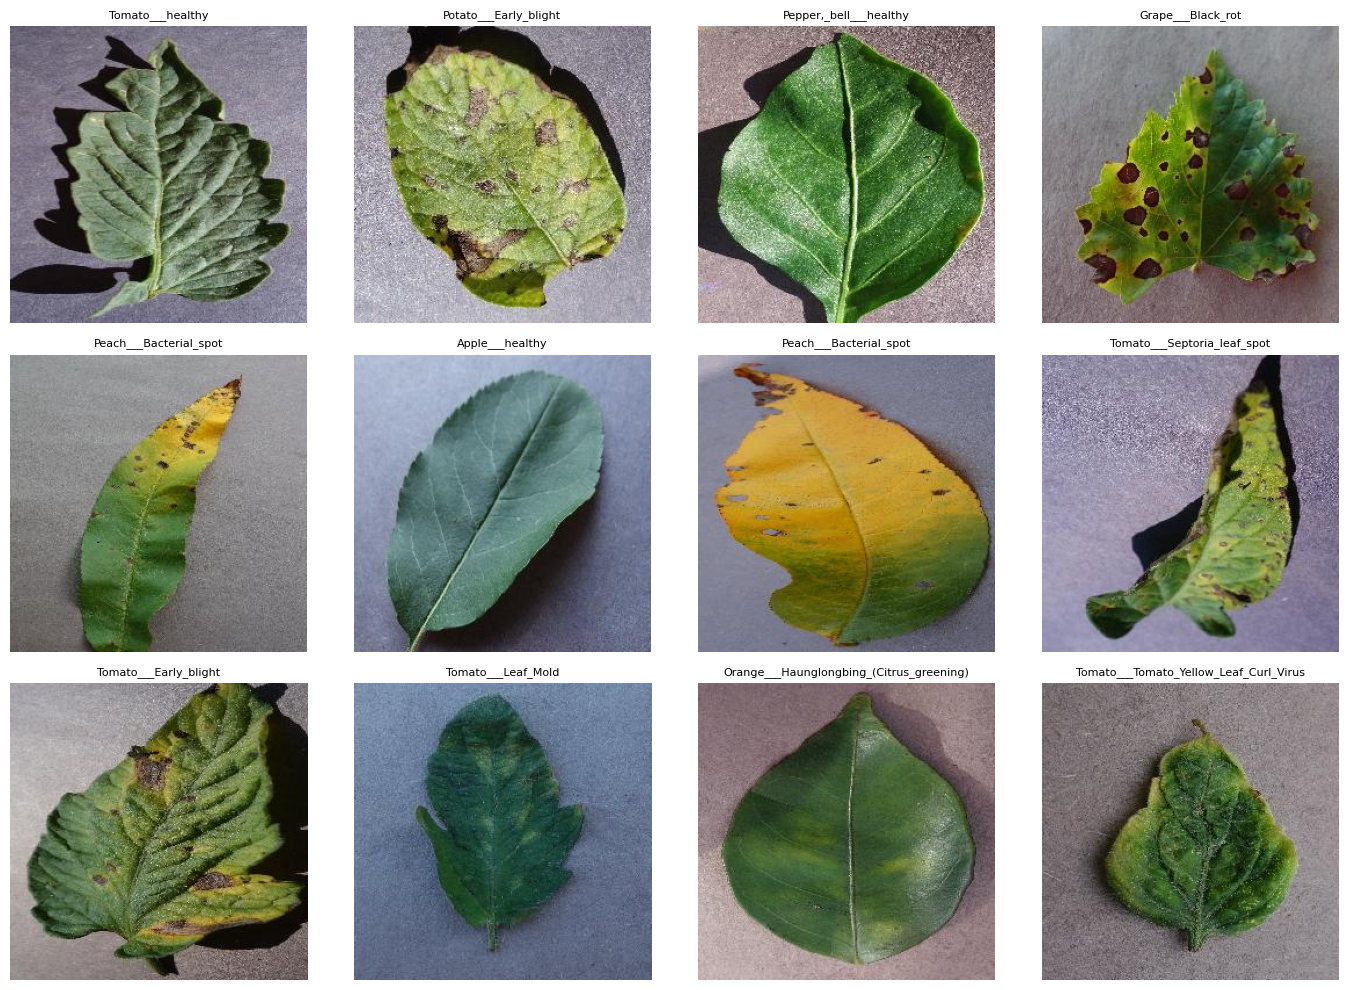

In [15]:
sample_df = train_df.sample(12, random_state=SEED)

plt.figure(figsize=(14, 10))
for i, row in enumerate(sample_df.itertuples(), 1):
    img = plt.imread(row.filepath)
    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(row.label, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Class Weights

In [16]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:")
for idx, weight in class_weights.items():
    print(idx, class_names[idx], ":", round(weight, 4))

Class weights:
0 Apple___Apple_scab : 2.2683
1 Apple___Black_rot : 2.2996
2 Apple___Cedar_apple_rust : 5.1831
3 Apple___healthy : 0.8684
4 Blueberry___healthy : 0.9518
5 Cherry_(including_sour)___Powdery_mildew : 1.3592
6 Cherry_(including_sour)___healthy : 1.6728
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 2.7865
8 Corn_(maize)___Common_rust_ : 1.1995
9 Corn_(maize)___Northern_Leaf_Blight : 1.4498
10 Corn_(maize)___healthy : 1.2304
11 Grape___Black_rot : 1.2111
12 Grape___Esca_(Black_Measles) : 1.0334
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1.3285
14 Grape___healthy : 3.3795
15 Orange___Haunglongbing_(Citrus_greening) : 0.2595
16 Peach___Bacterial_spot : 0.6221
17 Peach___healthy : 3.9696
18 Pepper,_bell___Bacterial_spot : 1.4332
19 Pepper,_bell___healthy : 0.9665
20 Potato___Early_blight : 1.4291
21 Potato___Late_blight : 1.4291
22 Potato___healthy : 9.4372
23 Raspberry___healthy : 3.8475
24 Soybean___healthy : 0.2808
25 Squash___Powdery_mildew : 0.7791
26 Strawber

# Bloque de Atención Espacial

In [24]:
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=kernel_size,
            padding="same",
            activation="sigmoid"  
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

# Arquitectura Propia: AgroVisionNet-Lite

In [25]:
def build_agrovisionnet_lite(
    input_shape=(224, 224, 3),
    num_classes=38,
    dropout_rate=0.35,
    train_backbone=False
):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # CNN Backbone
    backbone = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    backbone.trainable = train_backbone

    x = backbone(inputs, training=False)

    # Bloque propio de atención espacial
    x = SpatialAttention(name="spatial_attention")(x)

    # Reducción de canales antes de la parte recurrente
    x = layers.Conv2D(256, kernel_size=1, activation="relu", name="channel_projection")(x)
    x = layers.BatchNormalization(name="projection_bn")(x)

    # Convertimos el mapa 2D en secuencia espacial
    # Para 224x224 con MobileNetV2, normalmente queda 7x7.
    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]
    x = layers.Reshape((h * w, c), name="spatial_sequence")(x)

    # Modelado secuencial espacial
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=False),
        name="bigru_spatial"
    )(x)

    x = layers.BatchNormalization(name="gru_bn")(x)
    x = layers.Dropout(dropout_rate, name="dropout_gru")(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_features"
    )(x)

    x = layers.Dropout(dropout_rate, name="dropout_dense")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="classifier"
    )(x)

    model = Model(inputs, outputs, name="AgroVisionNet_Lite")

    return model


model = build_agrovisionnet_lite(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=class_count,
    dropout_rate=0.35,
    train_backbone=False
)

model.summary()

I0000 00:00:1779735514.087565      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779735514.089056      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "AgroVisionNet_Lite"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention               │ (None, 7, 7, 1280)     │            99 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_projection (Conv2D)     │ (None, 7, 7, 256)      │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_bn                   │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_sequence (Reshape)      │ (None, 49, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_spatial (Bidirectional)   │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_bn (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_gru (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,960,073 (11.29 MB)

 Trainable params: 701,065 (2.67 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

# Compilación - Fase 1

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Callbacks

In [32]:
checkpoint_path = os.path.join(OUTPUT_DIR, "best_agrovisionnet_lite.keras")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Entrenamiento - Fase 1

**Entrena cabeza + atención + BiGRU con backbone congelado**

In [35]:
history_head = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8259 - loss: 0.5700 - precision: 0.8899 - recall: 0.7691
Epoch 2: val_accuracy improved from 0.88841 to 0.90511, saving model to /kaggle/working/agrovisionnet_lite_all_classes/best_agrovisionnet_lite.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 499s 420ms/step - accuracy: 0.8259 - loss: 0.5700 - precision: 0.8899 - recall: 0.7691 - val_accuracy: 0.9051 - val_loss: 0.3269 - val_precision: 0.9396 - val_recall: 0.8727 - learning_rate: 1.0000e-04
Epoch 3/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8630 - loss: 0.4463 - precision: 0.9099 - recall: 0.8230
Epoch 3: val_accuracy improved from 0.90511 to 0.91566, saving model to /kaggle/working/agrovisionnet_lite_all_classes/best_agrovisionnet_lite.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 510s 429ms/step - accuracy: 0.8630 - loss: 0.4463 - precision: 0.9099 - recall: 0.8230 - val_accuracy: 0.9157 - val_loss: 0.2904 - val_precision: 0.9386 - val_recall: 0.8890 - learning

# Fine-Tuning - Fase 2

**Descongela parcialmente MobileNetV2**

In [36]:
backbone = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
        backbone = layer
        break

if backbone is None:
    print("No se encontró el backbone.")
else:
    backbone.trainable = True

    # Congelar capas iniciales y entrenar solo las últimas
    for layer in backbone.layers[:-40]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    history_fine = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=EPOCHS_FINE,
        class_weight=class_weights,
        callbacks=callbacks
    )

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.7843 - loss: 0.8173 - precision: 0.8342 - recall: 0.7510
Epoch 1: val_accuracy did not improve from 0.95212
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 501s 411ms/step - accuracy: 0.7843 - loss: 0.8171 - precision: 0.8342 - recall: 0.7511 - val_accuracy: 0.9206 - val_loss: 0.2790 - val_precision: 0.9328 - val_recall: 0.9151 - learning_rate: 1.0000e-05
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8797 - loss: 0.3888 - precision: 0.9050 - recall: 0.8602
Epoch 2: val_accuracy did not improve from 0.95212
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 492s 414ms/step - accuracy: 0.8798 - loss: 0.3888 - precision: 0.9050 - recall: 0.8602 - val_accuracy: 0.9333 - val_loss: 0.2233 - val_precision: 0.9459 - val_recall: 0.9271 - learning_rate: 1.0000e-05
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9076 - loss: 0.2937 - precision: 0.9276 - recall: 0.8939
Epoch 3: val_accuracy did not improve from 0.95212


# Evaluación en Test

In [37]:
best_model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={"SpatialAttention": SpatialAttention}
)

test_results = best_model.evaluate(test_gen, verbose=1)

metrics = dict(zip(best_model.metrics_names, test_results))
print(metrics)

with open(os.path.join(OUTPUT_DIR, "test_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'spatial_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


255/255 ━━━━━━━━━━━━━━━━━━━━ 72s 270ms/step - accuracy: 0.9699 - loss: 0.1229 - precision: 0.9735 - recall: 0.9656
{'loss': 0.12464665621519089, 'compile_metrics': 0.9694328308105469}


# Reporte de Clasificación

In [39]:
test_gen.reset()

preds = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

with open(os.path.join(OUTPUT_DIR, "classification_report.json"), "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4, ensure_ascii=False)


255/255 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98        94
                                 Apple___Black_rot       0.95      1.00      0.97        93
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        41
                                   Apple___healthy       0.99      0.97      0.98       246
                               Blueberry___healthy       0.99      1.00      0.99       226
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       158
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.76      0.92      0.84        77
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       179
               Corn_(maize)___Northe

# Matriz de Confusión

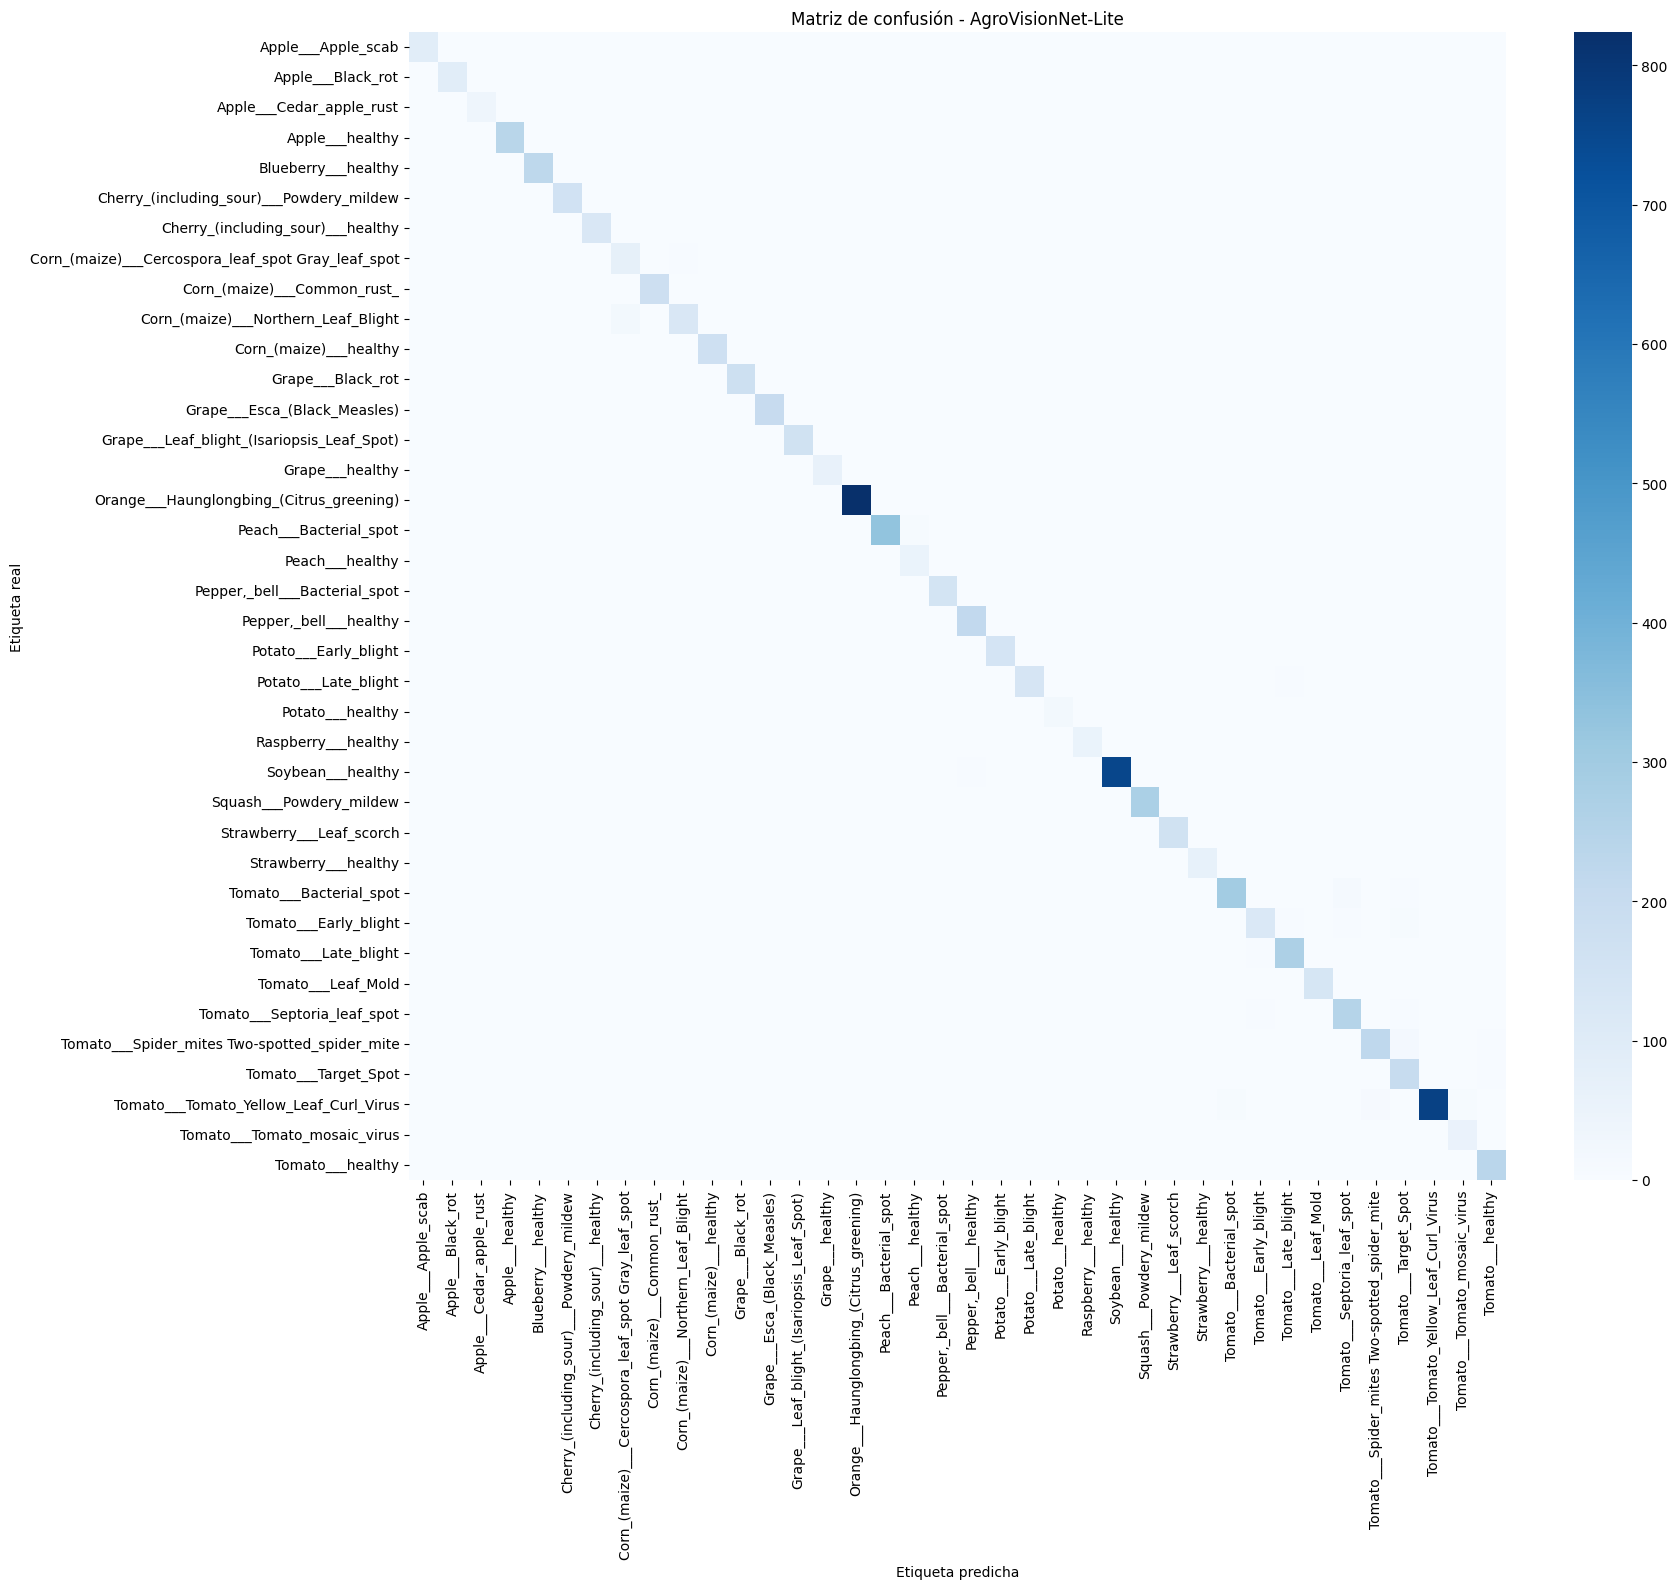

Matriz guardada en: /kaggle/working/agrovisionnet_lite_all_classes/confusion_matrix.png


In [40]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title("Matriz de confusión - AgroVisionNet-Lite")
plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Matriz guardada en:", cm_path)

# Curvas de Entrenamiento

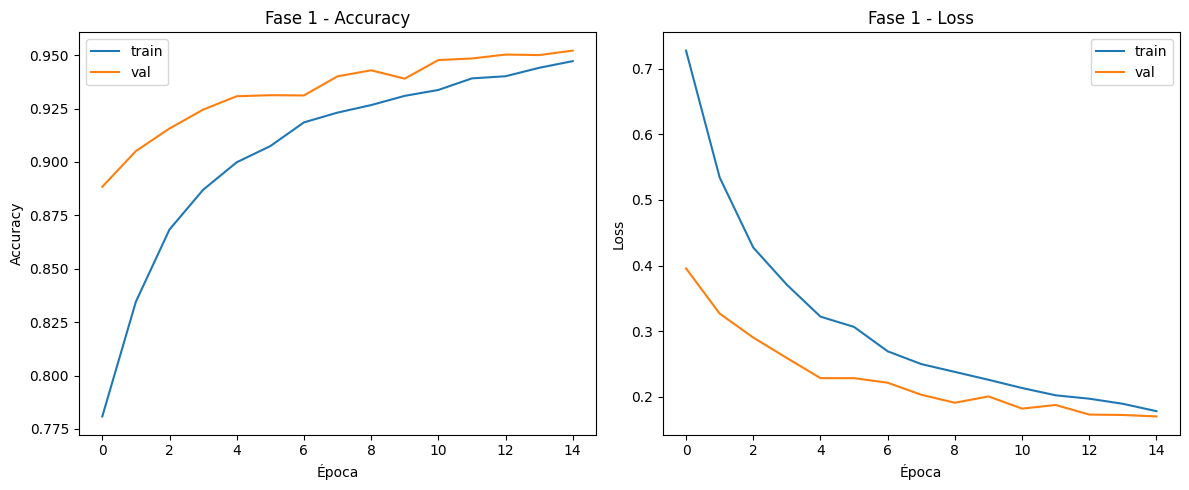

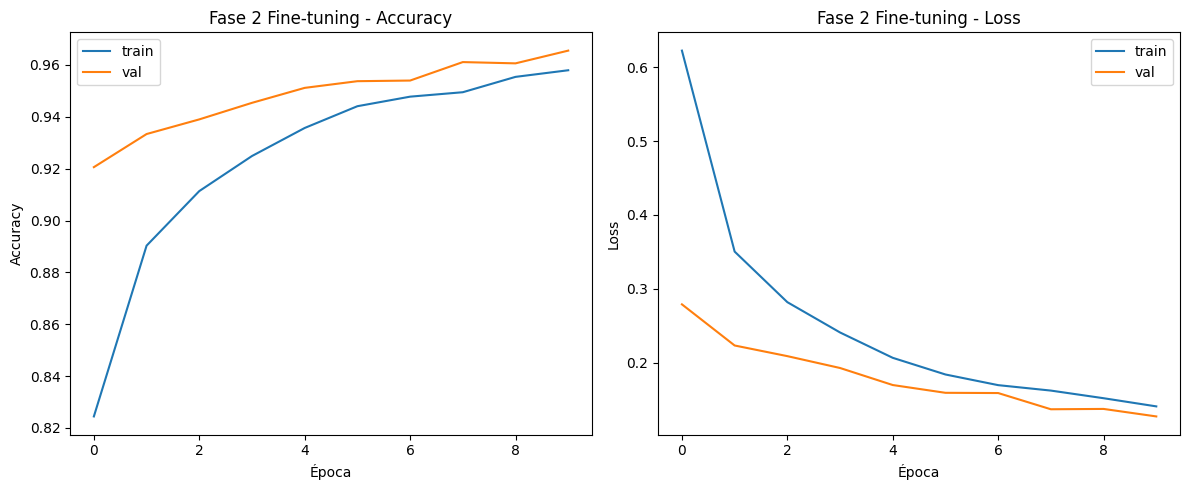

In [41]:
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_head, "Fase 1")

if "history_fine" in globals():
    plot_history(history_fine, "Fase 2 Fine-tuning")

# Guardar Modelo Final

In [42]:
final_model_path = os.path.join(OUTPUT_DIR, "agrovisionnet_lite_final.keras")
best_model.save(final_model_path)

print("Modelo final guardado en:", final_model_path)
print("Mejor modelo guardado en:", checkpoint_path)

Modelo final guardado en: /kaggle/working/agrovisionnet_lite_all_classes/agrovisionnet_lite_final.keras
Mejor modelo guardado en: /kaggle/working/agrovisionnet_lite_all_classes/best_agrovisionnet_lite.keras


## Justificación de la arquitectura propia

**AgroVisionNet-Lite** se plantea como una arquitectura híbrida para clasificación de enfermedades en plantas.

La propuesta combina:

1. **MobileNetV2** como extractor convolucional ligero.
2. **Atención espacial**, que permite resaltar regiones visualmente relevantes.
3. **BiGRU**, que interpreta el mapa de características como una secuencia espacial.
4. **Clasificador denso**, encargado de generar la predicción final.

Esta combinación permite integrar CNN, atención y redes recurrentes en una sola arquitectura propia, manteniendo eficiencia computacional y aplicabilidad en escenarios móviles.